## Библиотеки

In [1]:
import pandas as pd, numpy as np
import glob

import warnings
warnings.filterwarnings("ignore")

from datetime import datetime
from tqdm import tqdm

type_labels = {'clicks':1, 'carts':2, 'orders':3}

## Data

In [2]:
import os
os.environ['KAGGLE_USERNAME'] = 'sacr1ficer'
os.environ['KAGGLE_KEY'] = '66367a7dfd0f7f7db2159acab04cf6d8'

In [5]:
!kaggle datasets download columbia2131/otto-chunk-data-inparquet-format

Dataset URL: https://www.kaggle.com/datasets/columbia2131/otto-chunk-data-inparquet-format
License(s): unknown
 99% 1.67G/1.69G [00:09<00:00, 289MB/s]
100% 1.69G/1.69G [00:09<00:00, 195MB/s]


In [6]:
!unzip otto-chunk-data-inparquet-format.zip

Archive:  otto-chunk-data-inparquet-format.zip
  inflating: test_parquet/000000000_000100000.parquet  
  inflating: test_parquet/000100000_000200000.parquet  
  inflating: test_parquet/000200000_000300000.parquet  
  inflating: test_parquet/000300000_000400000.parquet  
  inflating: test_parquet/000400000_000500000.parquet  
  inflating: test_parquet/000500000_000600000.parquet  
  inflating: test_parquet/000600000_000700000.parquet  
  inflating: test_parquet/000700000_000800000.parquet  
  inflating: test_parquet/000800000_000900000.parquet  
  inflating: test_parquet/000900000_001000000.parquet  
  inflating: test_parquet/001000000_001100000.parquet  
  inflating: test_parquet/001100000_001200000.parquet  
  inflating: test_parquet/001200000_001300000.parquet  
  inflating: test_parquet/001300000_001400000.parquet  
  inflating: test_parquet/001400000_001500000.parquet  
  inflating: test_parquet/001500000_001600000.parquet  
  inflating: test_parquet/001600000_001700000.parquet  
 

In [3]:
def load(which, mx=75):
    dfs = []

    test_files = glob.glob('.//'+which+'_parquet/*')

    for e, chunk_file in tqdm(enumerate(test_files[:mx])):
        chunk = pd.read_parquet(chunk_file)
        chunk.ts = (chunk.ts/1000).astype('int32')
        chunk['type'] = chunk['type'].map(type_labels).astype('int8')
        dfs.append(chunk)

    return pd.concat(dfs).reset_index(drop=True)

In [7]:

train_df = load('train')

75it [00:25,  2.90it/s]


In [8]:
test_df = load('test')

17it [00:02,  7.53it/s]


In [9]:
train_df

,session,aid,ts,type
0,4000000,757471,1659706088,1
1,4000000,1195559,1659706113,1
2,4000000,374747,1659706122,1
3,4000000,989909,1659706160,1
4,4000000,1446091,1659706201,1
...,...,...,...,...
125421384,10599998,1000092,1661004149,1
125421385,10599998,1000092,1661022301,1
125421386,10599998,1000092,1661069632,1
125421387,10599999,832192,1661004149,1


## Возьмем последние 4 дня иначе колаб крашится

In [10]:
datetime.strptime("2022-08-25 00:00:00", "%Y-%m-%d %H:%M:%S").timestamp()

1661385600.0

In [11]:
sum(train_df['ts']>=1661385600)

17361439

In [12]:
train_df = train_df[train_df['ts']>=1661385600].reset_index(drop=True)

In [13]:
train_df['datetime'] = train_df['ts'].apply(lambda x: datetime.fromtimestamp(x))

In [14]:
train_df.shape

(17361439, 5)

In [15]:
train_df['session'].nunique()

2011190

In [16]:
train_df['aid'].nunique()

1146054

In [17]:
train_df

,session,aid,ts,type,datetime
0,4000001,235135,1661425672,1,2022-08-25 11:07:52
1,4000001,1731425,1661425702,1,2022-08-25 11:08:22
2,4000001,1815658,1661426112,1,2022-08-25 11:15:12
3,4000001,1504636,1661427948,1,2022-08-25 11:45:48
4,4000001,1731425,1661619485,1,2022-08-27 16:58:05
...,...,...,...,...,...
17361434,10599985,167673,1661520279,2,2022-08-26 13:24:39
17361435,10599985,1443660,1661520290,1,2022-08-26 13:24:50
17361436,10599985,1500675,1661520320,1,2022-08-26 13:25:20
17361437,10599985,1500675,1661520441,1,2022-08-26 13:27:21


## Выберем последний день как валидационный

In [18]:
train_df['datetime'].dt.day.unique()

array([25, 27, 28, 26], dtype=int32)

In [19]:
train_df['day'] = train_df['datetime'].dt.day

In [20]:
df_val_offline = train_df[train_df['day']==28].reset_index(drop=True)
df_train_offline = train_df[train_df['day']<28].reset_index(drop=True)

In [49]:
df_val_offline

,session,aid,ts,type,datetime,day
0,4000002,1520816,1661674947,1,2022-08-28 08:22:27,28
1,4000002,1458494,1661698189,1,2022-08-28 14:49:49,28
2,4000003,359668,1661679042,1,2022-08-28 09:30:42,28
3,4000003,359668,1661679128,1,2022-08-28 09:32:08,28
4,4000003,1243628,1661679167,1,2022-08-28 09:32:47,28
...,...,...,...,...,...,...
6247022,10599963,459694,1661690013,1,2022-08-28 12:33:33,28
6247023,10599963,1211995,1661690101,1,2022-08-28 12:35:01,28
6247024,10599963,1102662,1661690130,1,2022-08-28 12:35:30,28
6247025,10599974,979547,1661720593,1,2022-08-28 21:03:13,28


## Будем рекомендовать по популярности товаров

## Установим какие товары популярны

In [21]:
aid_pop_sta = df_train_offline.groupby(['aid','type'],as_index=False)['session'].count()

In [22]:
aid_pop_sta.columns = ['aid','type','pop']

In [23]:
aid_pop_sta

,aid,type,pop
0,0,1,1
1,1,1,2
2,2,1,1
3,3,1,302
4,3,2,36
...,...,...,...
1366064,1855594,3,5
1366065,1855599,1,1
1366066,1855600,1,3
1366067,1855600,2,1


## Топ 200 самых популярных

In [24]:
aid_pop_sta = aid_pop_sta.sort_values(['type','pop'],ascending=False).reset_index(drop=True)

In [25]:
aid_pop_sta

,aid,type,pop
0,876493,3,445
1,122983,3,277
2,373490,3,224
3,171982,3,221
4,1445562,3,179
...,...,...,...
1366064,1855579,1,1
1366065,1855583,1,1
1366066,1855587,1,1
1366067,1855599,1,1


In [26]:
top200_aid_click = list(aid_pop_sta.loc[aid_pop_sta['type']==1,'aid'][:200])
top200_aid_cart = list(aid_pop_sta.loc[aid_pop_sta['type']==2,'aid'][:200])
top200_aid_order = list(aid_pop_sta.loc[aid_pop_sta['type']==3,'aid'][:200])

## OПолучаем исторические данные по пользователям

In [27]:
target_users = list(df_val_offline['session'].unique() )

In [28]:
len(target_users)

879575

In [29]:
session_his = df_train_offline.loc[df_train_offline['session'].isin(target_users)].groupby(['session','type'],as_index=False)['aid'].agg(list)

In [30]:
session_his

,session,type,aid
0,0,1,"[1436439, 102416, 190818, 1157411, 138431, 543..."
1,0,2,"[275288, 974651, 543308, 543308, 442293, 15496..."
2,0,3,"[1199474, 543308]"
3,1,1,[1464360]
4,13,1,[1670763]
...,...,...,...
421859,12628733,1,[1525859]
421860,12628734,1,[70603]
421861,12628735,1,[25476]
421862,12628736,1,[1291256]


In [31]:
session_his['session'].nunique()

303633

**Только у 558344 из 1350502 юзеров вообще есть история**

In [32]:
his_click_dict = dict(zip(session_his.loc[session_his['type']==1,'session'],session_his.loc[session_his['type']==1,'aid']))
his_cart_dict = dict(zip(session_his.loc[session_his['type']==2,'session'],session_his.loc[session_his['type']==2,'aid']))
his_order_dict = dict(zip(session_his.loc[session_his['type']==3,'session'],session_his.loc[session_his['type']==3,'aid']))

## Рекомендуем пользователям на основе популярности товаров, исключая при этом товары, которые уже встречались в их истории.

In [33]:
res = []

for each_session in tqdm(target_users):

    if each_session in his_click_dict:
        his_click_tmp = his_click_dict[each_session]
        res.append([str(each_session)+'_clicks'] + [' '.join([str(x) for x in top200_aid_click if x not in his_click_tmp][:20])] )
    else:
        res.append([str(each_session)+'_clicks'] + [' '.join([str(x) for x in top200_aid_click][:20])])


    if each_session in his_cart_dict:
        his_cart_tmp = his_cart_dict[each_session]
        res.append([str(each_session)+'_carts'] + [' '.join([str(x) for x in top200_aid_cart if x not in his_cart_tmp][:20])] )
    else:
        res.append([str(each_session)+'_carts'] + [' '.join([str(x) for x in top200_aid_cart][:20])])

    if each_session in his_order_dict:
        his_order_tmp = his_order_dict[each_session]
        res.append([str(each_session)+'_orders'] + [' '.join([str(x) for x in top200_aid_order if x not in his_order_tmp][:20])] )
    else:
        res.append([str(each_session)+'_orders'] + [' '.join([str(x) for x in top200_aid_order][:20])])


100%|██████████| 879575/879575 [01:26<00:00, 10147.68it/s]


In [34]:
df_res = pd.DataFrame(res)

In [35]:
df_res

,0,1
0,4000002_clicks,876493 171982 1460571 108125 373490 1116095 18...
1,4000002_carts,876493 122983 171982 373490 166037 554660 1116...
2,4000002_orders,876493 122983 373490 171982 1445562 1531805 16...
3,4000003_clicks,876493 171982 1460571 108125 373490 1116095 18...
4,4000003_carts,876493 122983 171982 373490 166037 554660 1116...
...,...,...
2638720,10599974_carts,876493 122983 171982 373490 166037 554660 1116...
2638721,10599974_orders,876493 122983 373490 171982 1445562 1531805 16...
2638722,10599979_clicks,876493 171982 1460571 108125 373490 1116095 18...
2638723,10599979_carts,876493 122983 171982 373490 166037 554660 1116...


In [36]:
res_dict = dict(zip(df_res[0],df_res[1]))

## Валидация

In [37]:
session_items_val = df_val_offline.groupby(['session','type'],as_index=False)['aid'].agg(set)

In [38]:
session_items_val

,session,type,aid
0,0,1,"{843110, 543308, 1228848, 161938, 219925, 9380..."
1,1,1,"{207905, 497868, 376932, 1628317}"
2,2,1,"{808782, 690631, 485582, 1605711, 526287, 4653..."
3,2,2,{161269}
4,13,1,{22195}
...,...,...,...
1128728,12899774,1,"{33035, 1399483}"
1128729,12899775,1,"{1760714, 1743151}"
1128730,12899776,1,"{1737908, 548599}"
1128731,12899777,1,{384045}


In [39]:
session_items_val['session'].nunique()

879575

In [40]:
def getScore(df, type_, suffix):
    df_tmp = df[df['type']==type_].reset_index(drop=True)

    score_Numerator = 0
    score_Denominator = 0

    for i,row in tqdm( df_tmp.iterrows(),total=len(df_tmp) ):
        recom_tmp = [int(x) for x in res_dict[str(row['session'])+suffix].split(' ')]
        score_Numerator += len(row['aid'] & set(recom_tmp))
        score_Denominator += min(20,len(row['aid']))

    return score_Numerator/score_Denominator

In [41]:
score_click = getScore(session_items_val,1,'_clicks')

100%|██████████| 877888/877888 [00:57<00:00, 15208.74it/s]


In [42]:
score_cart = getScore(session_items_val,2,'_carts')

100%|██████████| 182808/182808 [00:12<00:00, 15057.92it/s]


In [43]:
score_order = getScore(session_items_val,3,'_orders')

100%|██████████| 68037/68037 [00:04<00:00, 16659.73it/s]


In [44]:
score_click * 0.1 + score_cart * 0.3 + score_order * 0.6

0.007611009003493423

# Submission

In [50]:
test = test_df.reset_index(drop=True)

In [56]:
target_users_test = list(test['session'].unique())

In [58]:
session_items_test = test.groupby(['session','type'],as_index=False)['aid'].agg(set)

In [59]:
res = []

for each_session in tqdm(target_users_test):

    if each_session in his_click_dict:
        his_click_tmp = his_click_dict[each_session]
        res.append([str(each_session)+'_clicks'] + [' '.join([str(x) for x in top200_aid_click if x not in his_click_tmp][:20])] )
    else:
        res.append([str(each_session)+'_clicks'] + [' '.join([str(x) for x in top200_aid_click][:20])])


    if each_session in his_cart_dict:
        his_cart_tmp = his_cart_dict[each_session]
        res.append([str(each_session)+'_carts'] + [' '.join([str(x) for x in top200_aid_cart if x not in his_cart_tmp][:20])] )
    else:
        res.append([str(each_session)+'_carts'] + [' '.join([str(x) for x in top200_aid_cart][:20])])

    if each_session in his_order_dict:
        his_order_tmp = his_order_dict[each_session]
        res.append([str(each_session)+'_orders'] + [' '.join([str(x) for x in top200_aid_order if x not in his_order_tmp][:20])] )
    else:
        res.append([str(each_session)+'_orders'] + [' '.join([str(x) for x in top200_aid_order][:20])])


100%|██████████| 1671803/1671803 [02:27<00:00, 11367.50it/s]


In [60]:
submission = pd.DataFrame(res)

In [63]:
submission.columns = ['session_type', 'labels']

In [67]:
submission

,session_type,labels
0,13599779_clicks,876493 171982 1460571 108125 373490 1116095 18...
1,13599779_carts,876493 122983 171982 373490 166037 554660 1116...
2,13599779_orders,876493 122983 373490 171982 1445562 1531805 16...
3,13599780_clicks,876493 171982 1460571 108125 373490 1116095 18...
4,13599780_carts,876493 122983 171982 373490 166037 554660 1116...
...,...,...
5015404,14499777_carts,876493 122983 171982 373490 166037 554660 1116...
5015405,14499777_orders,876493 122983 373490 171982 1445562 1531805 16...
5015406,14499778_clicks,876493 171982 1460571 108125 373490 1116095 18...
5015407,14499778_carts,876493 122983 171982 373490 166037 554660 1116...


In [68]:
submission.to_csv('submission.csv', index=False)

In [70]:
with open('submission.csv') as f:
  for i in range(5):
    print(f.readline().strip())

session_type,labels
13599779_clicks,876493 171982 1460571 108125 373490 1116095 184976 1551213 1126038 1531805 1254630 554660 29735 959208 96165 832192 332654 322370 801774 1236775
13599779_carts,876493 122983 171982 373490 166037 554660 1116095 1531805 1022566 1460571 923948 1534690 332654 1445562 544144 231487 29735 322370 801774 832192
13599779_orders,876493 122983 373490 171982 1445562 1531805 166037 923948 231487 332654 801774 1534690 1460571 1257293 1022566 1025795 1476166 544144 986164 756588
13599780_clicks,876493 171982 1460571 108125 373490 1116095 184976 1551213 1126038 1531805 1254630 554660 29735 959208 96165 832192 332654 322370 801774 1236775


In [71]:
!kaggle competitions submit otto-recommender-system -f submission.csv -m "pls more than 0.000"

100% 773M/773M [00:07<00:00, 109MB/s]
Successfully submitted to OTTO – Multi-Objective Recommender System

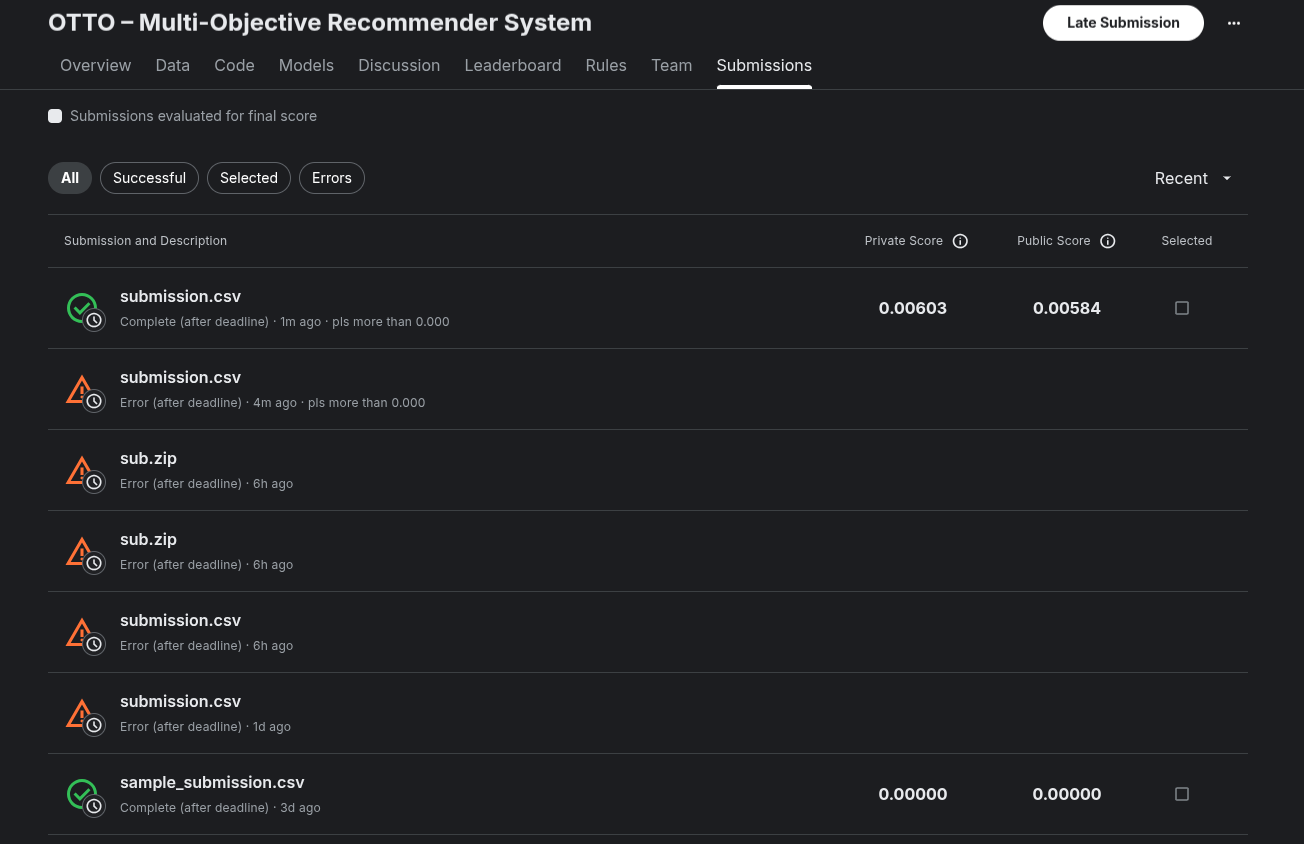

# Итоги

Это ужас насколько эта задача оказалась сложнее, чем я думал. Датасет грузится часами и у меня бесконечно крашится ядро и все надо перезапускать заново. Я не нашел ни одного ноутбука, где будет хоть какой-то бейзлайн и все пришлось собирать руками по разным ноутбукам. В итоге вместо пары часов я потратил два дня на это замечательной задание. Качество получилось потрясающе низким, но хотя бы оно не нулевое! Я читал в обсуждениях, что люди неделями решают это соревнование, и бейзлайн засылают только через неделю после начала, так что я доволен, что хоть что-то получилось.